<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

dataset = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

drop_cols = ["SEQN", "LBXGH", "diabetes_label", "diabetes_binary"]
X = dataset.drop(columns=drop_cols)
y = dataset["diabetes_label"]
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")

Train: 3627 | Val: 1209 | Test: 1209


In [ ]:
tier1_cols = [
    "RIDAGEYR", "RIAGENDR", "RIDRETH3",
    "BMXBMI", "BMXWAIST",
    "BPXSY_mean", "BPXDI_mean"
]
tier2_cols = tier1_cols + [
    "LBXTC", "LBXTR",
    "LBXSCR", "LBXSUA", "LBXSBU"
]
tier3_cols = tier2_cols + [
    "LBXSATSI", "LBXSASSI",
    "LBXSTP", "LBXSAL", "LBXSCA",
    "LBXSPH", "LBXSNASI", "LBXSKSI",
    "LBXSGB", "LBXSC3SI"
]

In [ ]:
def kmeans(X, K, max_iter=300, tol=1e-4, random_state=42):
    rng = np.random.default_rng(random_state)
    N, d = X.shape
    centers = np.empty((K, d))
    centers[0] = X[rng.integers(0, N)]
    for k in range(1, K):
        dists = np.min(((X[:, None, :] - centers[:k][None, :, :]) ** 2).sum(-1), axis=1)
        probs = dists / dists.sum()
        centers[k] = X[rng.choice(N, p=probs)]

    for it in range(max_iter):
        d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
        labels = np.argmin(d2, axis=1)
        new_centers = np.array([
            X[labels == k].mean(axis=0) if (labels == k).any() else centers[k]
            for k in range(K)
        ])
        if np.linalg.norm(new_centers - centers) < tol:
            break
        centers = new_centers

    inertia = ((X - centers[labels]) ** 2).sum()
    return labels, centers, inertia


X_train_t3 = x_train[tier3_cols].values
y_train_arr = y_train.values

mu = X_train_t3.mean(axis=0)
sd = X_train_t3.std(axis=0) + 1e-9
X_std = (X_train_t3 - mu) / sd

print(f"Clustering {X_std.shape[0]} patients on {X_std.shape[1]} Tier 3 features")

Clustering 3627 patients on 22 Tier 3 features


K=3: inertia=68440, silhouette=0.088
K=4: inertia=65069, silhouette=0.079
K=5: inertia=62218, silhouette=0.083
K=6: inertia=60250, silhouette=0.070


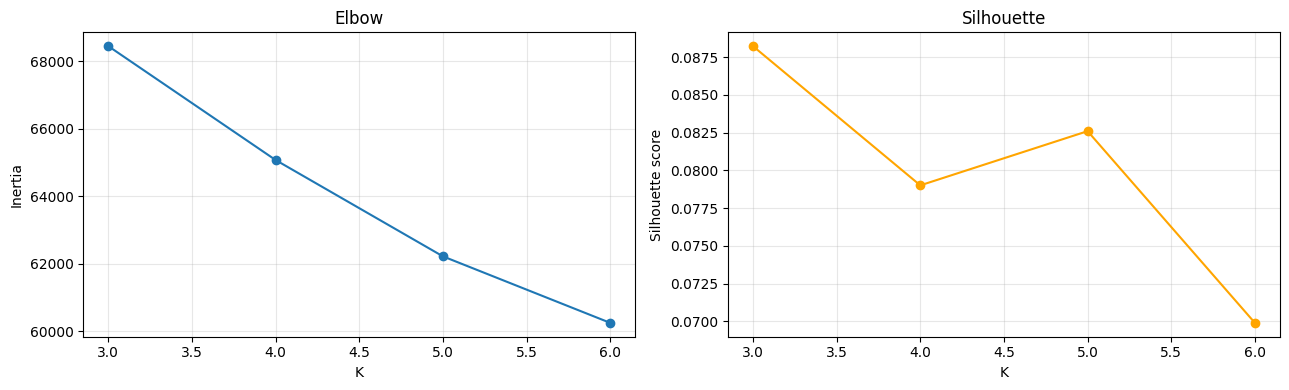

In [ ]:
K_values = [3, 4, 5, 6]
inertias, silhouettes = [], []

rng_sil = np.random.default_rng(42)
sample_idx = rng_sil.choice(len(X_std), size=min(1500, len(X_std)), replace=False)

for K in K_values:
    labels_k, _, inertia_k = kmeans(X_std, K, random_state=42)
    sil = silhouette_score(X_std[sample_idx], labels_k[sample_idx])
    inertias.append(inertia_k); silhouettes.append(sil)
    print(f"K={K}: inertia={inertia_k:.0f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_values, inertias, marker='o'); axes[0].set_title('Elbow'); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(K_values, silhouettes, marker='o', color='orange'); axes[1].set_title('Silhouette')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
K_chosen = 3

labels_train, centers, _ = kmeans(X_std, K_chosen, random_state=42)
np.savez(
    'kmeans_artifacts.npz',
    centers=centers,
    mu=mu,
    sd=sd,
    train_labels=labels_train,
    tier3_cols=np.array(tier3_cols, dtype=object),
    K_chosen=np.int64(K_chosen),
)
print(f"Saved kmeans_artifacts.npz (K={K_chosen})")

Saved kmeans_artifacts.npz (K=3)


Patient counts per cluster:
label    Healthy  Prediabetic  Diabetic
cluster                                
0            467          443       218
1            600          392       201
2           1128          146        32

Within-cluster class proportions:
label    Healthy  Prediabetic  Diabetic
cluster                                
0          0.414        0.393     0.193
1          0.503        0.329     0.168
2          0.864        0.112     0.025


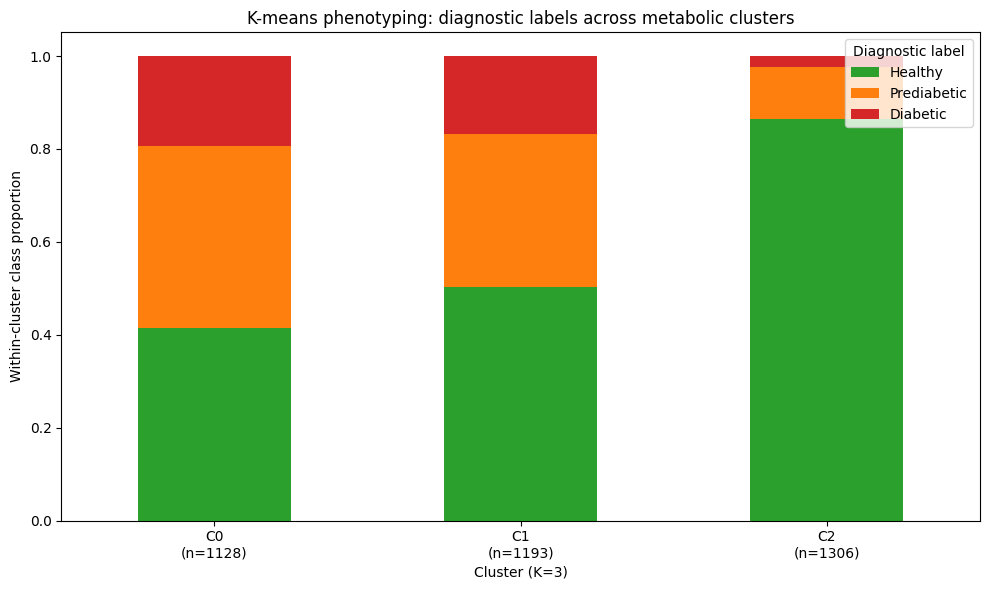

In [ ]:
class_names = {0: 'Healthy', 1: 'Prediabetic', 2: 'Diabetic'}
df_cluster = pd.DataFrame({
    'cluster': labels_train,
    'label': [class_names[c] for c in y_train_arr]
})
counts = pd.crosstab(df_cluster['cluster'], df_cluster['label'])[['Healthy', 'Prediabetic', 'Diabetic']]
proportions = counts.div(counts.sum(axis=1), axis=0).round(3)

print("Patient counts per cluster:"); print(counts)
print("\nWithin-cluster class proportions:"); print(proportions)

fig, ax = plt.subplots(figsize=(10, 6))
proportions.plot(kind='bar', stacked=True, ax=ax, color=['#2ca02c', '#ff7f0e', '#d62728'])
ax.set_xlabel(f'Cluster (K={K_chosen})')
ax.set_ylabel('Within-cluster class proportion')
ax.set_title('K-means phenotyping: diagnostic labels across metabolic clusters')
ax.legend(title='Diagnostic label', loc='upper right')
ax.set_xticklabels([f'C{i}\n(n={counts.iloc[i].sum()})' for i in range(K_chosen)], rotation=0)
plt.tight_layout(); plt.savefig('cluster_composition.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
centers_original = centers * sd + mu
deviations = (centers_original - X_train_t3.mean(axis=0)) / (X_train_t3.std(axis=0) + 1e-9)

print("Cluster characterization (z-scores vs. dataset mean):\n")
for k in range(K_chosen):
    print(f"--- Cluster {k} (n={counts.iloc[k].sum()}, diabetic rate={proportions.iloc[k]['Diabetic']:.1%}) ---")
    cluster_z = pd.Series(deviations[k], index=tier3_cols).sort_values(key=abs, ascending=False)
    for feat, z in cluster_z.head(5).items():
        direction = '↑' if z > 0 else '↓'
        print(f"  {feat:12s}  z = {z:+.2f}  {direction}")
    print()

Cluster characterization (z-scores vs. dataset mean):

--- Cluster 0 (n=1128, diabetic rate=19.3%) ---
  RIDAGEYR      z = +0.91  ↑
  LBXSBU        z = +0.69  ↑
  LBXSTP        z = -0.51  ↓
  BPXSY_mean    z = +0.51  ↑
  LBXSCR        z = +0.43  ↑

--- Cluster 1 (n=1193, diabetic rate=16.8%) ---
  BMXBMI        z = +0.71  ↑
  BMXWAIST      z = +0.65  ↑
  LBXSGB        z = +0.65  ↑
  LBXSAL        z = -0.41  ↓
  BPXDI_mean    z = +0.40  ↑

--- Cluster 2 (n=1306, diabetic rate=2.5%) ---
  RIDAGEYR      z = -0.85  ↓
  BMXWAIST      z = -0.81  ↓
  BMXBMI        z = -0.67  ↓
  BPXSY_mean    z = -0.67  ↓
  LBXSAL        z = +0.49  ↑



In [ ]:
cluster_ids = labels_train
true_labels = y_train_arr

print(f"KMeans evaluation (k={K_chosen})")
print(f"  Silhouette score:           {silhouette_score(X_std, cluster_ids):.4f}")
print(f"  Adjusted Rand Index (ARI):  {adjusted_rand_score(true_labels, cluster_ids):.4f}")
print(f"  Normalized Mutual Info:     {normalized_mutual_info_score(true_labels, cluster_ids):.4f}")
print("\nPer-cluster purity (dominant label fraction):")
for c in sorted(np.unique(cluster_ids)):
    mask = cluster_ids == c
    counts = np.bincount(true_labels[mask], minlength=3)
    purity = counts.max() / counts.sum()
    dom = ['Normal','Pre-diab','Diabetic'][counts.argmax()]
    print(f"  Cluster {c}: n={mask.sum()}, purity={purity:.3f} (dominant: {dom})")

KMeans evaluation (k=3)
  Silhouette score:           0.0867
  Adjusted Rand Index (ARI):  0.0964
  Normalized Mutual Info:     0.0905

Per-cluster purity (dominant label fraction):
  Cluster 0: n=1128, purity=0.414 (dominant: Normal)
  Cluster 1: n=1193, purity=0.503 (dominant: Normal)
  Cluster 2: n=1306, purity=0.864 (dominant: Normal)
